# **Libraries**

In [ ]:
import os
import sys
import subprocess
import glob

# 🎛️ SET THIS TO TRUE FOR TPU, FALSE FOR GPU
FORCE_TPU = False

def repair_environment():

    if FORCE_TPU:
        print("🔍 Starting High-Speed TPU Repair...")

        # 1. Faster Uninstallation
        print("🧹 Wiping libraries...")
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q",
                        "torch", "torch_xla", "torchvision", "numpy", "tensorflow", "huggingface_hub"],
                       capture_output=True)

        # 2. Parallel/Bulk Installation
        print("📥 Installing Synced TPU Stack...")
        common_args = ["install", "-q", "--no-warn-script-location"]

        if FORCE_TPU or glob.glob("/dev/accel*"):
            cmd = [
                sys.executable, "-m", "pip", *common_args,
                "torch==2.8.0",
                "torchvision==0.23.0",
                "torch_xla[tpu]==2.8.0",
                "numpy", "pyarrow", "fsspec",
                "protobuf>=5.28.0",
                "datasets", "transformers", "huggingface_hub>=0.28.0", "wandb",
                "cloud-tpu-client", "scikit-learn", "pandas<3.0.0",
                "-f", "https://storage.googleapis.com/libtpu-releases/index.html",
                "--extra-index-url", "https://download.pytorch.org/whl/cpu"
            ]
            subprocess.check_call(cmd)
        else:
            # Fallback
            cmd = [
                sys.executable, "-m", "pip", *common_args, "-U",
                "torch", "datasets", "pyarrow", "transformers", "huggingface_hub>=0.28.0", "fsspec", "wandb", "scipy", "numpy", "pandas<3.0.0"
            ]
            subprocess.check_call(cmd)

        print("\n✅ TPU REPAIR COMPLETE.")
        print("⚠️ Click 'Run' -> 'Restart Session' NOW.")

    else:
        print("🔍 Starting Robust GPU Repair...")

        # 1. Clean Wipe
        print("🧹 Wiping conflicting libraries...")
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q",
                        "torch", "torchvision", "torchaudio", "huggingface_hub"],
                       capture_output=True)

        # 2. Setup Arguments
        common_args = ["install", "-q", "--no-warn-script-location"]

        try:
            print("📥 Installing GPU/CUDA Stack...")

            print("   ⚡ Part 1: PyTorch Core...")
            subprocess.check_call([
                sys.executable, "-m", "pip", *common_args,
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu121"
            ])

            print("   ⚡ Part 2: Transformers & Data...")
            subprocess.check_call([
                sys.executable, "-m", "pip", *common_args, "-U",
                "datasets", "transformers==4.48.0", "huggingface_hub>=0.28.0",
                "wandb", "pandas<3.0.0", "pyarrow<16.0.0" # <-- ADDED PYARROW CAP HERE
            ])

            print("\n✅ GPU REPAIR COMPLETE.")
            print("⚠️ MANDATORY: Click 'Run' -> 'Restart Session' NOW.")

        except subprocess.CalledProcessError as e:
            print(f"\n❌ Installation failed. Error: {e}")
            print("💡 Try manually restarting the session and running this cell again.")

if __name__ == "__main__":
    repair_environment()

In [1]:
import io
import os
import sys
import time
import json
import site
import torch
import wandb
import warnings
import importlib
import numpy as np
import multiprocessing
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import torch.nn as nn
from transformers import ModernBertModel, AutoConfig, AutoTokenizer
from torch.utils.data import DataLoader
from dataclasses import dataclass, field
from datasets import load_dataset, Dataset
from typing import Optional, List, Union, ClassVar, Dict, Any
from huggingface_hub import hf_hub_download, create_repo, HfApi
from huggingface_hub.utils import RepositoryNotFoundError, EntryNotFoundError
# Ensure PJRT runtime gets selected, not XRT
for key in ["XRT_TPU_CONFIG", "PJRT_SELECT_DEVICE", "TPU_PROCESS_ADDRESSES"]:
    os.environ.pop(key, None)
os.environ["PJRT_DEVICE"] = "TPU"
# Add the framework quarantine just in case!
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Prevent C++ thread deadlocks during 10B token streaming
os.environ["OMP_NUM_THREADS"] = "1"
import pyarrow as pa
pa.set_cpu_count(1)
pa.set_io_thread_count(1)
# Tell everything to stay away from the TPU except PyTorch
os.environ["USE_TORCH"] = "1"
os.environ["USE_TF"] = "0"
os.environ["USE_JAX"] = "0"

# Force Path Refresh
if 'site' in sys.modules:
    importlib.reload(site)

# Get HF_TOKEN and WANDB_API_KEY
def get_secret(key_name):

    # Try Colab
    try:
        from google.colab import userdata
        return userdata.get(key_name)
    except:
        pass

    # Try Kaggle
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(key_name)
    except:
        pass

    # Local Env
    return os.getenv(key_name)

# Get the float value of something (mainly for losses)
def to_float(x):
    return x.item() if hasattr(x, 'item') else float(x)

# Globals

hf_token = get_secret("HF_TOKEN")
model_repo_id = "JamesResearch1216/ModernBERT-BT_Easiness_v5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2026-06-03 22:13:17.172189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780524797.401468     146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780524797.454520     146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780524797.949852     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780524797.949886     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780524797.949889     146 computation_placer.cc:177] computation placer alr

# **Loading the Model**

In [3]:
import torch.nn as nn
from transformers import ModernBertModel

class RegressionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.modernBert = ModernBertModel(config)
        self.regression_head = nn.Sequential(
            nn.Linear(768, 256),
            nn.LayerNorm(256),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.modernBert(input_ids=input_ids, attention_mask=attention_mask)

        # [batch_size, seq_len, hidden_size]
        last_hidden = outputs.last_hidden_state

        # Adds extra last dimension and broadcast to all hidden dims
        # [batch_size, seq_len] -> [batch_size, seq_len, 1] -> [batch_size, seq_len, hidden_size]
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()

        # Sum the logits along token (seq_len) dimension
        sum_embeddings = torch.sum(last_hidden * mask, 1)

        # Sum total logits
        sum_mask = mask.sum(1)

        # Find Average
        mean_pooled = sum_embeddings / sum_mask

        # Pass new logits to regression head
        logits = self.regression_head(mean_pooled)

        return {"logits": logits}






In [4]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True
def load_model(model_repo_id):
    try:
        hf_hub_download(
            repo_id = model_repo_id,
            filename = "model.pt",
            repo_type = "model",
            token = hf_token,
            local_dir = "."
        )
    
        hf_hub_download(
            repo_id = model_repo_id,
            filename = "config.json",
            repo_type = "model",
            token = hf_token,
            local_dir = "."
        )
        
    except Exception as e:
        raise RuntimeError(f"Critical HF Download Failure for {filename}: {e}")

    config = AutoConfig.from_pretrained("./config.json")
    
    model = RegressionModel(config)

    state_dict = torch.load("./model.pt", weights_only = True)

    model.load_state_dict(state_dict)
    
    model.eval()
    
    return model


trained_model = load_model(model_repo_id)
trained_model.to(device)
tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")


model.pt:   0%|          | 0.00/597M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [ ]:
# # inputs = tokenizer("The oscillating pendulum did not merely cleave the atmospheric damp; it bifurcated the immediate perceptual continuum, rendering the aforementioned 'now' into a shattered mosaic of 'thens' and 'yets'. We stood, peripheral to the brass escapement, observing the horologist whose arthritic phalanges manipulated the counterweights with a paralytic, almost liturgic grace. It was an exercise in profound futility, this desperate imposition of Newtonian discrete geometry upon the unyielding fluidity of the Bergsonian *durée*. The ambient dust motes, caught in the crepuscular slant of an anemic autumnal lethargy, seemed less like tangible particulate matter and more like the fragmented syntax of a forgotten, pre-Babel dialectic, swirling in Brownian apathy. He turned the arbor. A sharp click resounded—not vibrating within the tympanic cavity, but echoing, hollow and vast, against the ontological absolute.To apprehend the gear is to deliberately ignore the inevitability of the rust; yet, to valorize the rust is to prematurely succumb to the entropic certainty that renders all epistemological frameworks utterly moot. I—for the collective \'we\' of my internal perspective had spontaneously sheared into a fractured, isolated singular ego, catalyzed by the sudden, discordant chime of the quarter-hour—found myself plunging into the interstitial void suspended between the tick and its resultant tock. Was it precisely here, within this microscopic chasm of chronometric latency, that the much-debated homunculus of free will resided? Or was it merely the deterministic shudder of an already-written, inexorable cosmogony playing out its mechanical farce? The horologist cleared his throat. It was a wet, staccato punctuation mark that violently disrupted my phenomenological reverie, abruptly grounding the transcendent calculus of interlocking gears back into the fragile, somatic reality of pulmonary decay and cellular senescence. He proffered the extracted mainspring, his eyes reflecting the dull patina of tarnished bronze. \"It recoils,\" he muttered. Yet, the phonemes blurred into an undifferentiated hum of sibilance, stripped of their semantic anchor. The coil lay dormant upon his palm, a metallic Fibonacci spiral perfectly capturing the essence of recursive, unavoidable doom. It mirrored the labyrinthine convolutions of our own mnemonic architectures, where every retrieved memory inevitably alters the neurochemical substrate of the engram itself, creating an ever-shifting palimpsest of fabricated, overlapping histories. I reached out to accept the offering, but my hand, transfixed by the cruel hysteresis of its own kinetic trajectory, remained agonizingly suspended. We were irrevocably caught in the asymptotic approach to a zenith we could neither name nor endure, perpetually falling toward a focal point that retreated with each successive, desperate cognitive grasp. The pendulum swung back; the universe contracted.", truncation = True, padding = "max_length", max_length = 512, attention_mask = True, return_tensors = "pt")
# inputs = tokenizer("The shimmering subsided, leaving a taste like static on my tongue and the unsettling sensation of being… unmoored. For centuries, I'd chased the phantom of longevity, dissecting ancient texts, funding obscure research, pushing the boundaries of cellular regeneration. And finally, in a forgotten lab beneath the Argentinian salt flats, I'd cracked it. Not a fountain of youth, not a magical elixir, but a meticulous re-wiring of the telomeres, a bio-acoustic resonance keyed to the earth's magnetic field. I was, irrevocably, immortal.", truncation = True, padding = "max_length", max_length = 512, attention_mask = True, return_tensors = "pt")

# print(inputs)
# print(trained_model(input_ids = inputs["input_ids"].to(device), attention_mask = inputs["attention_mask"].to(device)))

# **Tokenizing Function**

In [5]:
def tokenizing_function(example, col_name):
    input = tokenizer(example[col_name], 
        padding = "max_length", 
        max_length = 512, 
        truncation = True, 
        return_tensors = "pt", 
        return_attention_mask = True, 
        return_token_type_ids = False
    )
    input["input_ids"] = input["input_ids"].squeeze()
    input["attention_mask"] = input["attention_mask"].squeeze()

    return input

def get_dataloader(data_repo_id, split = None, name = None, col_name = None):

    dataset = load_dataset(
        path = data_repo_id,
        name = name,
        split = split,
        token = hf_token,
        streaming = True
    )

    shuffled_ds = dataset.shuffle(seed=42)
    random_chunk = shuffled_ds.take(1024)

    random_chunk = random_chunk.map(tokenizing_function, fn_kwargs={"col_name": col_name})

    def collate_fn(batch):
        input_ids = [item["input_ids"] for item in batch]
        attention_masks = [item["attention_mask"] for item in batch]
    
        # Some datasets return tensors, others return lists — handle both
        if isinstance(input_ids[0], torch.Tensor):
            return {
                "input_ids": torch.stack(input_ids),
                "attention_mask": torch.stack(attention_masks)
            }
        else:
            return {
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "attention_mask": torch.tensor(attention_masks, dtype=torch.long)
            }

    data_loader = DataLoader(
        random_chunk,
        batch_size = 16,
        drop_last = True,
        pin_memory = False,
        collate_fn = collate_fn
    )

    return data_loader

def generate_output(data_loader):
    outputs_array = np.full(1024, fill_value=0.0, dtype=np.float32)
    input_strs = []
    with torch.no_grad():
        for step, batch in enumerate(data_loader):
            input_ids = batch["input_ids"].to(device)
            decoded_batch = tokenizer.decode(input_ids[0], skip_special_tokens=True)
            input_strs.append(decoded_batch)
            attention_mask = batch["attention_mask"].to(device)
            outputs = trained_model(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs["logits"].squeeze().clamp(0,1).cpu().numpy()
            batch_size = logits.shape[0]
            start_idx = step * batch_size
            end_idx = start_idx + batch_size
            outputs_array[start_idx:end_idx] = logits
        return (outputs_array, input_strs)

# **Output Information**

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histogram_and_table(data, input_strs):
    # 1. Plot the histogram
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=20, range=(0, 1), edgecolor='black', color='skyblue')
    plt.xlabel('Logit Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Model Logits')
    plt.show()

    # 2. Print the table
    print(f"{'Logit':<10} | {'Excerpt'}")
    print("-" * 60)
    
    # We step by 16 because that is the batch size in your dataloader
    # This aligns the index with the saved input_strs
    for i, logit_val in enumerate(data[::16]):
        if i < len(input_strs):
            text = input_strs[i].replace('\n', ' ') # Truncate and clean text
            print(f"{logit_val:<10.4f} | {text}...")
        

In [ ]:
dl = get_dataloader("HuggingFaceFW/fineweb-edu", split = "train", name = "sample-10BT", col_name = "text")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("roneneldan/TinyStories", split = "train", col_name = "text")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("SimpleStories/SimpleStories", split = "train", col_name = "story")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("UniverseTBD/arxiv-abstracts-large", split = "train", col_name = "abstract")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("japhba/pubmed_simple", split = "train", col_name = "abstract")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("VibrantVista/TTCW-Based-Review", split = "train", col_name = "regenerated_story")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("pszemraj/simple_wikipedia_LM", name = "default", split = "train", col_name = "text")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

In [ ]:
dl = get_dataloader("sentence-transformers/reddit-title-body", split = "train", col_name = "body")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/174M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125] WON'T CONVERT compiled_embeddings /usr/local/lib/python3.12/dist-packages/transformers/models/modernbert/modeling_modernbert.py line 206 
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125] due to: 
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125] Traceback (most recent call last):
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125]   File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/output_graph.py", line 1446, in _call_user_compiler
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0603 22:15:28.430000 146 torch/_dynamo/convert_frame.py:1125]   File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/repro/after_dynamo.py", line 129, in __call__
W0603 22:15:28.430000 146 torch/_dynamo/c

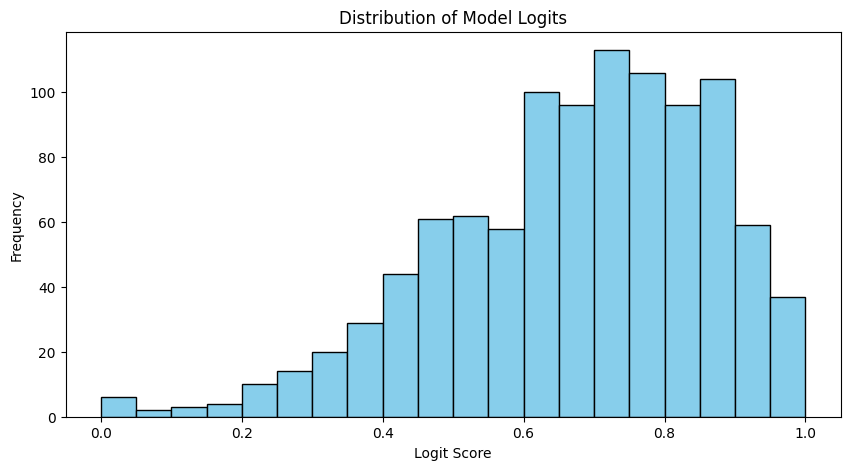

Logit      | Excerpt
------------------------------------------------------------
0.5505     | All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make....
0.4735     | I was given the FL100 as a gift and soon realized the product is flawed. If the player is connected to the PC and the battery dies, it will corrupt the internal memory and the player will not restart after replacing the battery. The player BIOS will initiate, however, once the internal memory check is complete the message "Battery Low!!!

In [7]:
dl = get_dataloader("yassiracharki/Amazon_Reviews_Binary_for_Sentiment_Analysis", split = "train", col_name = "review_text")
logits, input_strs = generate_output(dl)
plot_histogram_and_table(logits, input_strs)